In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
linear_package = joblib.load("../trained_model/linear_reg_model.joblib")
svm_package = joblib.load("../trained_model/svm_reg_model.joblib")
rf_package = joblib.load("../trained_model/random_forest_reg_model.joblib")

In [3]:
training_data = pd.read_csv("../datasets/real_estate_properties_data_cleaned.csv")
testing_data = pd.read_csv("../datasets/real_estate_properties_final_testing_cleaned.csv")

In [4]:
X_train = training_data.copy().drop(columns = "price")
y_train = training_data["price"].copy()
X_test = testing_data.copy().drop(columns = "price")
y_test = testing_data["price"].copy()

In [5]:
scaling_columns = [
    "num_bath",
    "num_bed",
    "num_parking",
    "property_size",
    "day",
    "month",
    "year"
]

In [6]:
scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scaling_columns] = scaler.fit_transform(
    X_train[scaling_columns]
)

X_test_scaled[scaling_columns] = scaler.transform(
    X_test[scaling_columns]
)

In [7]:
def cross_validation(model : str, params, cv : KFold, Xtraining: pd.DataFrame, ytraining: np.array) -> list:
    fold_results = []
    mae_results = []
    rmse_results = []
    r2_results = []
    for fold, (train_index, validation_index) in enumerate(cv.split(Xtraining)):

        X_fold_train = Xtraining.iloc[train_index]
        X_fold_validation = Xtraining.iloc[validation_index]

        y_fold_train = ytraining.iloc[train_index]
        y_fold_validation = ytraining.iloc[validation_index]

        if model == "lasso":
            fold_model = Lasso(
                **params,
                max_iter = 50000000
            )
        elif model == "svm":
            fold_model = SVR(
                **params
            )
        elif model == "random forest":
            fold_model = RandomForestRegressor(
                **params
            )
        else:
            print(f"Do not support model {model} !")
            break

        fold_model.fit(X_fold_train, y_fold_train)

        validation_predictions = fold_model.predict(X_fold_validation)

        mae = mean_absolute_error(y_fold_validation, validation_predictions)
        mae_results.append(mae)

        rmse = root_mean_squared_error(y_fold_validation, validation_predictions)
        rmse_results.append(rmse)

        r2 = r2_score(y_fold_validation, validation_predictions)
        r2_results.append(r2)

    fold_results.append({
        "MAE": np.array(mae_results).mean(),
        "RMSE": np.array(rmse_results).mean(),
        "R2": np.array(r2_results).mean()
    })

    return fold_results

In [8]:
kf = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [9]:
lasso_fold = cross_validation("lasso", linear_package["hyperparameters"], kf, X_train_scaled, y_train)
svm_fold = cross_validation("svm", svm_package["hyperparameters"], kf, X_train_scaled, y_train)
rf_fold = cross_validation("random forest", rf_package["hyperparameters"], kf, X_train, y_train)

In [10]:
results = pd.DataFrame(
    [{"Model": "Lasso", **row} for row in lasso_fold]
    + [{"Model": "SVR", **row} for row in svm_fold]
    + [{"Model": "Random Forest", **row} for row in rf_fold]
)

print(results)

           Model           MAE          RMSE        R2
0          Lasso  1.470475e+06  2.257789e+06 -0.242449
1            SVR  1.403207e+06  3.293353e+06 -0.130062
2  Random Forest  8.940147e+05  2.114809e+06  0.035485


In [11]:
rf_model = RandomForestRegressor(
    **rf_package["hyperparameters"]
)

rf_model.fit(X_train, y_train)

rf_test_predictions = rf_model.predict(X_test)
rf_train_predictions = rf_model.predict(X_train)

In [12]:
rf_train_mse = mean_squared_error(y_train, rf_train_predictions)
rf_test_mse = mean_squared_error(y_test, rf_test_predictions)
rf_train_mae = mean_absolute_error(y_train, rf_train_predictions)
rf_test_mae = mean_absolute_error(y_test, rf_test_predictions)
rf_train_rmse = root_mean_squared_error(y_train, rf_train_predictions)
rf_test_rmse = root_mean_squared_error(y_test, rf_test_predictions)
rf_train_r2 = r2_score(y_train, rf_train_predictions)
rf_test_r2 = r2_score(y_test, rf_test_predictions)

In [13]:
rf_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        rf_train_mse,
        rf_train_mae,
        rf_train_rmse,
        rf_train_r2
    ],
    "Testing": [
        rf_test_mse,
        rf_test_mae,
        rf_test_rmse,
        rf_test_r2
    ]
})

rf_melt_results = rf_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(rf_results)

  Metric      Training       Testing
0    MSE  3.094770e+12  1.692736e+12
1    MAE  6.503072e+05  8.102161e+05
2   RMSE  1.759196e+06  1.301052e+06
3     R2  7.445350e-01  8.406781e-01


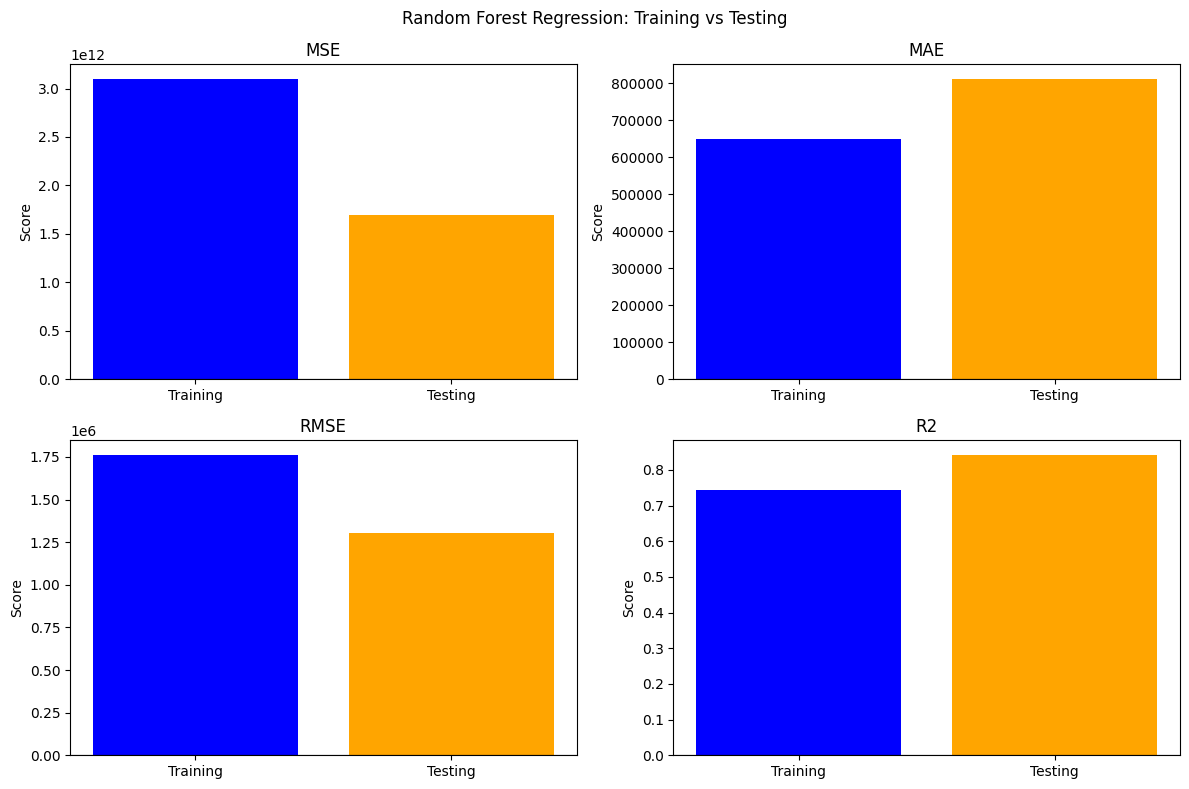

In [14]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, rf_results["Metric"]):
    metric_data = rf_melt_results[rf_melt_results["Metric"] == metric]

    ax.bar(
        metric_data["Dataset"],
        metric_data["Score"],
        color = metric_data["Dataset"].map({
            "Training": "blue",
            "Testing": "orange"
        })
    )

    ax.axhline(0, color = "black", linewidth = 0.8)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("Random Forest Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [15]:
lasso_model = Lasso(
    **linear_package["hyperparameters"],
    max_iter = 50000000
)

lasso_model.fit(X_train_scaled, y_train)

las_test_predictions = lasso_model.predict(X_test_scaled)
las_train_predictions = lasso_model.predict(X_train_scaled)

In [16]:
las_train_mse = mean_squared_error(y_train, las_train_predictions)
las_test_mse = mean_squared_error(y_test, las_test_predictions)
las_train_mae = mean_absolute_error(y_train, las_train_predictions)
las_test_mae = mean_absolute_error(y_test, las_test_predictions)
las_train_rmse = root_mean_squared_error(y_train, las_train_predictions)
las_test_rmse = root_mean_squared_error(y_test, las_test_predictions)
las_train_r2 = r2_score(y_train, las_train_predictions)
las_test_r2 = r2_score(y_test, las_test_predictions)

In [17]:
las_results = pd.DataFrame({
    "Metric": [
        "MSE",
        "MAE",
        "RMSE",
        "R2"
    ],
    "Training": [
        las_train_mse,
        las_train_mae,
        las_train_rmse,
        las_train_r2
    ],
    "Testing": [
        las_test_mse,
        las_test_mae,
        las_test_rmse,
        las_test_r2
    ]
})

las_melt_results = las_results.melt(
    id_vars = "Metric",
    var_name = "Dataset",
    value_name = "Score"
)

print(las_results)

  Metric      Training       Testing
0    MSE  3.378457e+12  2.561839e+12
1    MAE  1.157697e+06  1.164617e+06
2   RMSE  1.838058e+06  1.600575e+06
3     R2  7.211174e-01  7.588773e-01


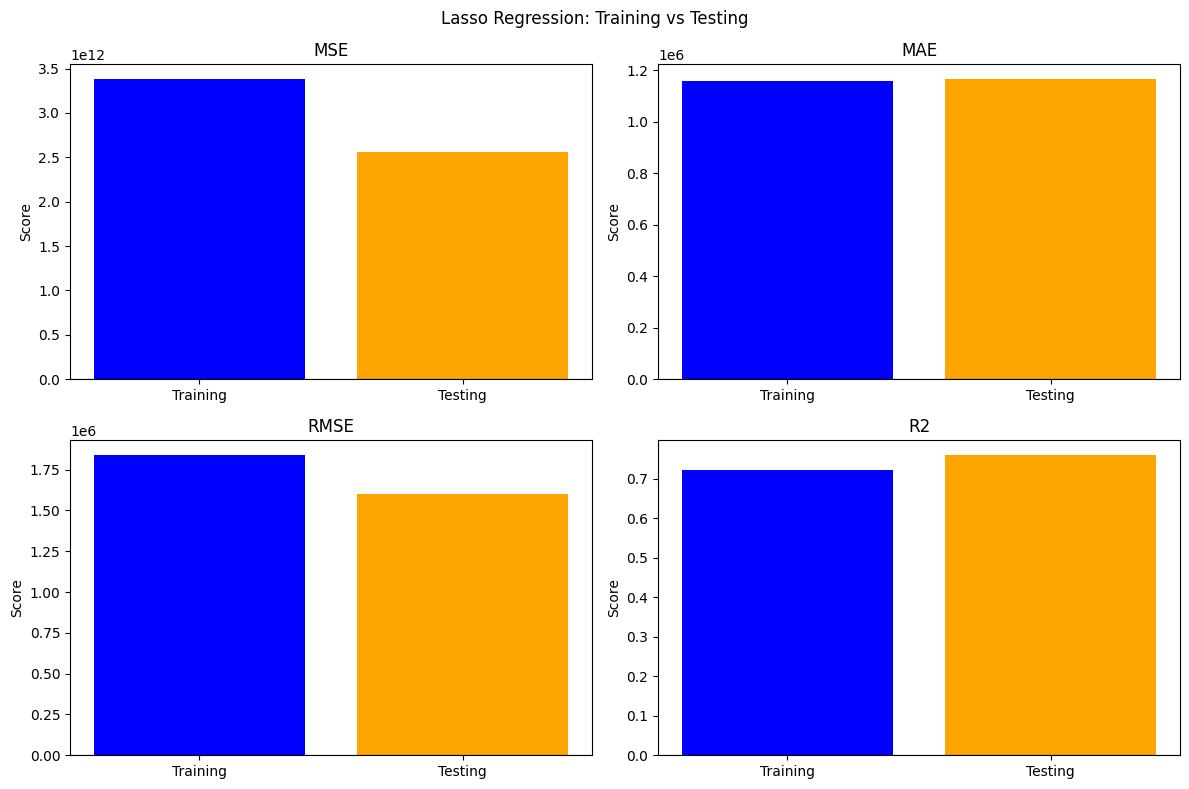

In [18]:
fig, axes = plt.subplots(2, 2, figsize = (12, 8))

for ax, metric in zip(axes.flat, las_results["Metric"]):
    metric_data = las_melt_results[las_melt_results["Metric"] == metric]

    ax.bar(
        metric_data["Dataset"],
        metric_data["Score"],
        color = metric_data["Dataset"].map({
            "Training": "blue",
            "Testing": "orange"
        })
    )

    ax.axhline(0, color = "black", linewidth = 0.8)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("Score")

fig.suptitle("Lasso Regression: Training vs Testing")
plt.tight_layout()
plt.show()

In [19]:
predictions = rf_model.predict(X_test)

error_table = X_test.copy()
error_table["actual_price"] = y_test.to_numpy()
error_table["predicted_price"] = predictions

''' 
Positive (error > 0) = Over prediction
Negative (error < 0) = Under prediction
'''
error_table["error"] = error_table["predicted_price"] - error_table["actual_price"]

error_table["absolute_error"] = error_table["error"].abs()

error_table["percentage_error"] = (error_table["absolute_error"] / error_table["actual_price"]) * 100

In [20]:
suburb_columns = ["blacktown", "mosman", "parramatta"]

type_columns = [
    "Apartment",
    "Block of units",
    "Duplex/semi-detached",
    "House",
    "Townhouse",
    "Unit"
]

error_table["suburb"] = error_table[suburb_columns].idxmax(axis = 1)
error_table["type"] = error_table[type_columns].idxmax(axis = 1)

top_five = error_table.nlargest(5, "absolute_error")

columns = [
    "suburb", "type",
    "num_bed", "num_bath", "num_parking", "property_size",
    "actual_price", "predicted_price",
    "error", "absolute_error", "percentage_error"
]

print(top_five[columns].round(2).to_string())

       suburb   type  num_bed  num_bath  num_parking  property_size  actual_price  predicted_price       error  absolute_error  percentage_error
6      mosman  House      5.0       2.0          2.0          524.8     7100000.0       3664078.23 -3435921.77      3435921.77             48.39
2      mosman  House      4.0       3.0          4.0          660.0    11360000.0       8047551.77 -3312448.23      3312448.23             29.16
21  blacktown  House      4.0       2.0          2.0          876.0     1300000.0       3726240.35  2426240.35      2426240.35            186.63
4      mosman  House      5.0       3.0          2.0          904.0     9650000.0      11592239.55  1942239.55      1942239.55             20.13
17  blacktown  House      3.0       1.0          2.0          834.0     1225000.0       3073155.30  1848155.30      1848155.30            150.87


In [21]:
original_data = pd.read_csv("../datasets/real_estate_properties_data.csv")
top_five["source_url"] = original_data.loc[top_five.index, "source_url"]
top_five["source_url"]

6     https://www.realestate.com.au/sold/property-ap...
2     https://www.realestate.com.au/sold/property-ap...
21    https://www.realestate.com.au/sold/property-ho...
4     https://www.realestate.com.au/sold/property-to...
17    https://www.realestate.com.au/sold/property-un...
Name: source_url, dtype: str

                 Feature  Importance
0               num_bath    0.572853
3          property_size    0.279045
8                 mosman    0.048584
6                   year    0.028783
1                num_bed    0.028676
5                  month    0.026866
2            num_parking    0.007624
4                    day    0.007055
13                 House    0.000371
15                  Unit    0.000071
9             parramatta    0.000033
7              blacktown    0.000029
10             Apartment    0.000010
11        Block of units    0.000000
12  Duplex/semi-detached    0.000000
14             Townhouse    0.000000


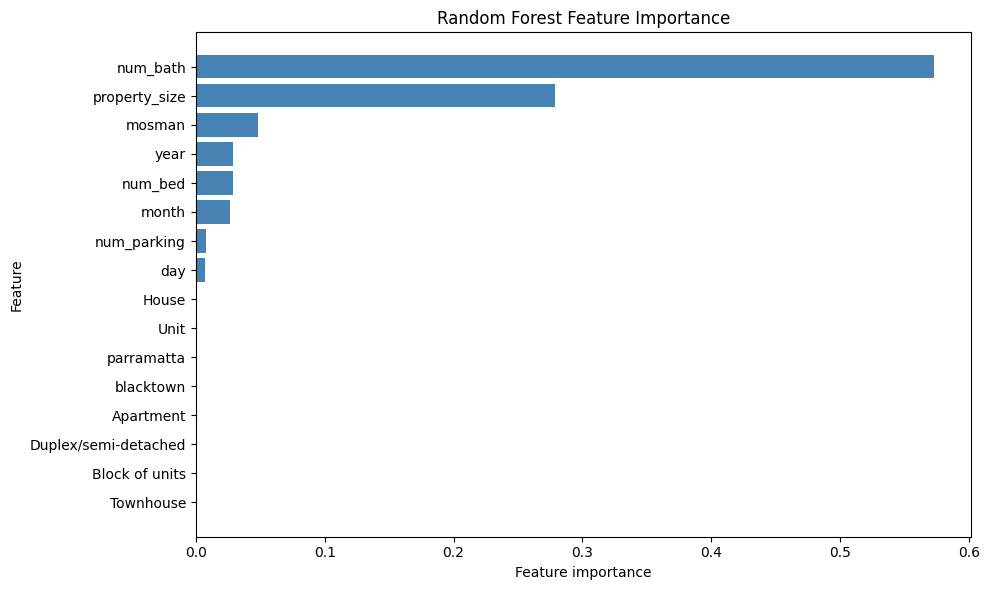

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending = False)

print(feature_importance)

plot_data = feature_importance.sort_values("Importance")

plt.figure(figsize = (10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"],
    color = "steelblue"
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()